In [5]:
from rfdetr import RFDETRSegNano
from PIL import Image
import numpy as np
import os


# model = RFDETRSegNano(device="cuda")

# model.train(
#     dataset_dir="datasets/processed/exp2.4-dv3train_organized_coco",
#     epochs=1, 
#     batch_size=1,
#     grad_accum_steps=16,
#     lr=1e-4,
#     output_dir="runs/exp2_4_dv3train_rfdetrsegnano",
#     # gradient_checkpointing=True,
#     resolution=60,
#     wandb=True,
#     project="Oil-Spill-UAV",
#     run="exp2.4-dv3train-rfdetrsegnano",
#     # resume="output/checkpoint.pth"
#     # num_select=100  # Reduce from default 300 for smaller datasets
# )

model = RFDETRSegNano(pretrain_weights="runs/exp2.4-dv3train_rfdetrsegnano/checkpoint_best_total.pth", device="cuda")
model.optimize_for_inference()
image = Image.open("/home/robby/workspace/Oil-Spill-Benz/DV4/images/20240725_多哥籍「阿諾(ALANO)」貨輪疑似流錨協處案/20240825/UAV_20240825_sophia_0306.jpg")
detections = model.predict(image, threshold=0.5)



Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
Using patch size 12 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
Loading pretrain weights


In [3]:
detections.mask

array([], shape=(0, 2268, 4032), dtype=bool)

In [ ]:
if detections.mask is not None:
    print("Mask shape:", detections.mask.shape)
    pred_mask = np.any(detections.mask, axis=0)  # Combine all instance masks into one binary mask
    print("Combined mask shape:", pred_mask.shape)

In [ ]:
for image in os.listdir("/home/robby/workspace/Oil-Spill-Benz/DV4/images/20240725_多哥籍「阿諾(ALANO)」貨輪疑似流錨協處案/20240825/"):
    if image.endswith(".jpg"):
        image_path = os.path.join("/home/robby/workspace/Oil-Spill-Benz/DV4/images/20240725_多哥籍「阿諾(ALANO)」貨輪疑似流錨協處案/20240825/", image)
        img = Image.open(image_path)
        detections = model.predict(img, threshold=0.5)
        print(f"Detections for {image}:")
        print(detections)
        if detections.mask is not None:
            print("Mask shape:", detections.mask.shape)
            pred_mask = np.any(detections.mask, axis=0)  # Combine all instance masks into one binary mask
            print("Combined mask shape:", pred_mask.shape)
            # save combined mask as an image
            mask_image = Image.fromarray(pred_mask.astype(np.uint8) * 255)
            output_dir = "runs/exp2.4_dv3train_rfdetrsegnano/test/masks"
            os.makedirs(output_dir, exist_ok=True)
            mask_image.save(os.path.join(output_dir, f"{os.path.splitext(image)[0]}_mask.png"))

Detections for UAV_20240825_sophia_0374.jpg:
Detections(xyxy=array([], shape=(0, 4), dtype=float32), mask=array([], shape=(0, 2250, 4000), dtype=bool), confidence=array([], dtype=float32), class_id=array([], dtype=int64), tracker_id=None, data={}, metadata={})
Mask shape: (0, 2250, 4000)
Combined mask shape: (2250, 4000)
Detections for UAV_20240825_sophia_0327.jpg:
Detections(xyxy=array([], shape=(0, 4), dtype=float32), mask=array([], shape=(0, 2970, 5280), dtype=bool), confidence=array([], dtype=float32), class_id=array([], dtype=int64), tracker_id=None, data={}, metadata={})
Mask shape: (0, 2970, 5280)
Combined mask shape: (2970, 5280)
Detections for UAV_20240825_sophia_0329.jpg:
Detections(xyxy=array([[1760.1249, 1184.9288, 2764.0398, 2602.0317]], dtype=float32), mask=array([[[False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        ...,
        [False, False, False, ...,

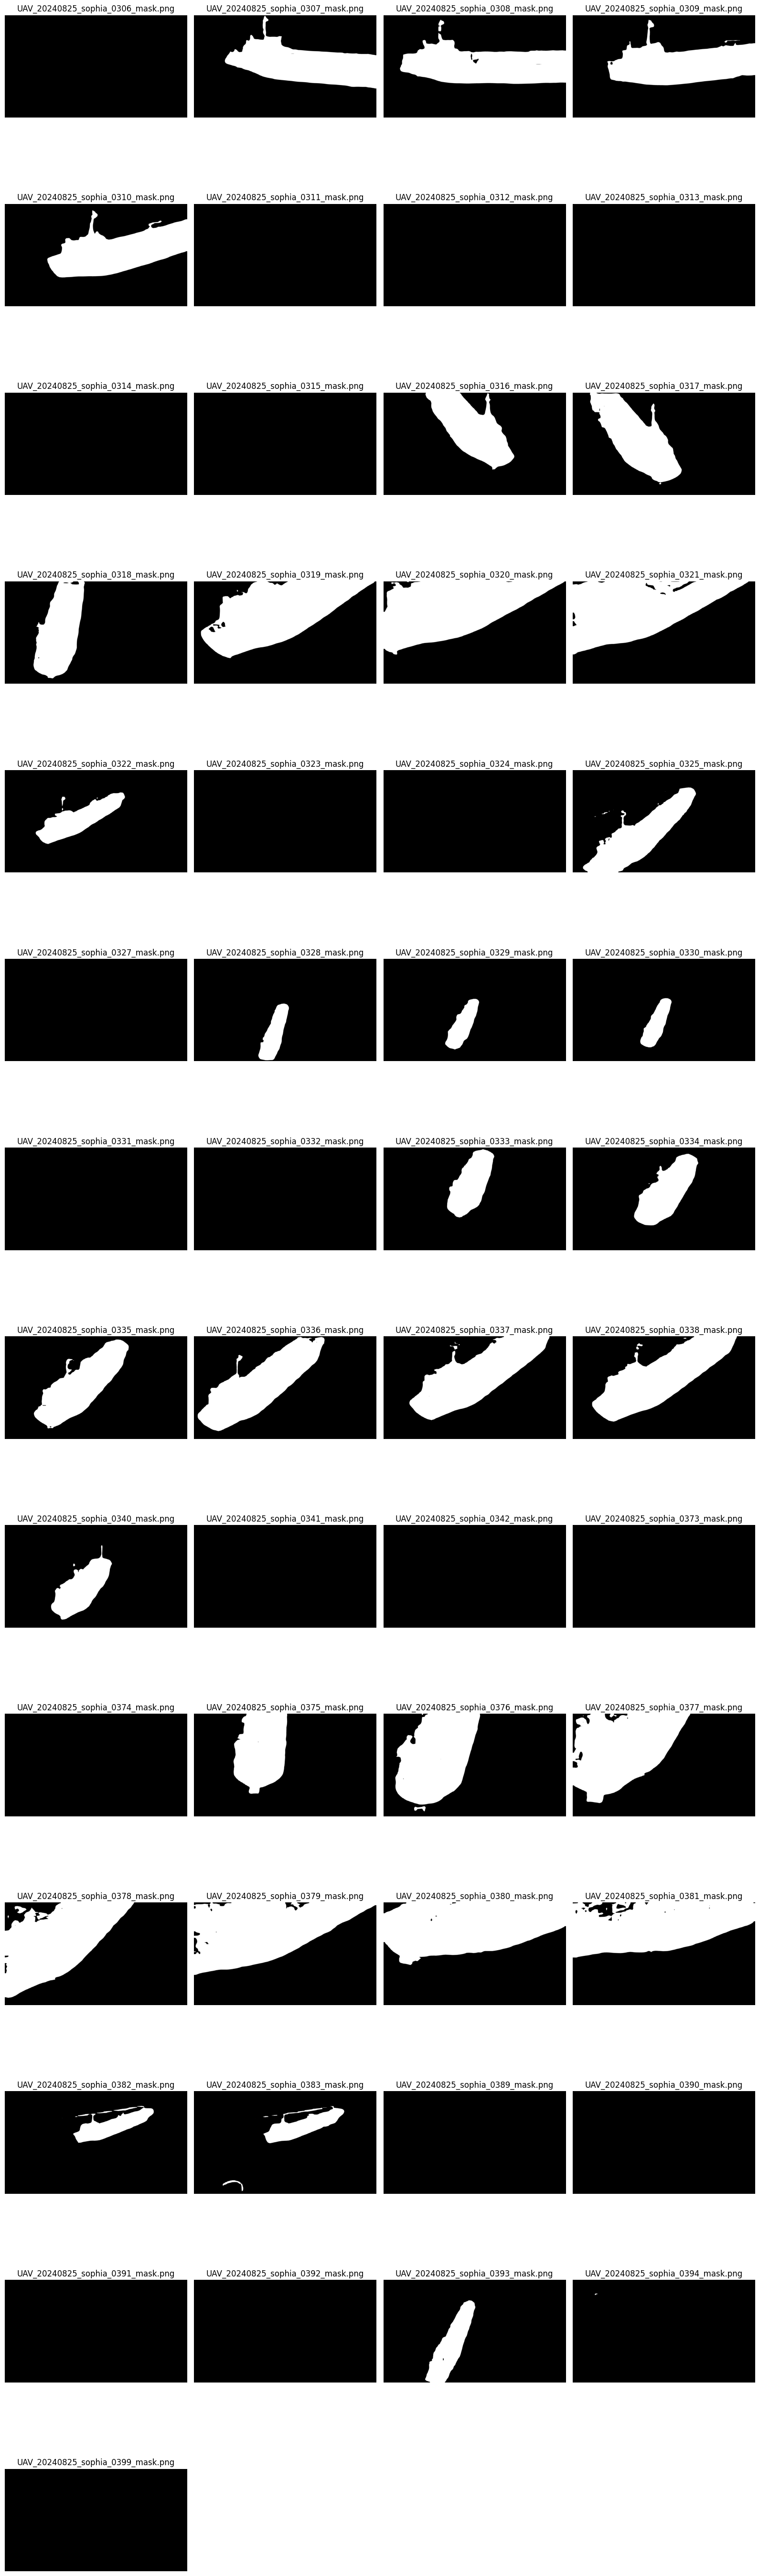

In [12]:
# plot all predictions and masks inside the directory
import os
from PIL import Image
import matplotlib.pyplot as plt

output_dir = "runs/exp2.4_dv3train_rfdetrsegnano/test/masks"

image_files = [
    f for f in sorted(os.listdir(output_dir))
    if f.lower().endswith((".png", ".jpg", ".jpeg"))
 ]

if not image_files:
    print("No images found in:", output_dir)
else:
    cols = 4
    rows = (len(image_files) + cols - 1) // cols
    plt.figure(figsize=(4 * cols, 4 * rows))
    for idx, filename in enumerate(image_files, start=1):
        img = Image.open(os.path.join(output_dir, filename))
        plt.subplot(rows, cols, idx)
        plt.imshow(img, cmap="gray")
        plt.title(filename)
        plt.axis("off")
    plt.tight_layout()
    plt.show()

In [3]:
from PIL import Image
import supervision as sv
import os
import cv2

oil_classes = {
    0: "oil"
}
test_images_path = "datasets/processed/exp2.1_rfdetr_inc-split_organized_coco/test"
output_images_path = "output/test/exp2.1_rfdetr_inc-split/"

for image_name in os.listdir(test_images_path):
    # get only jpg and png files
    if not image_name.endswith((".jpg", ".png")):
        continue
    
    image = Image.open(os.path.join(test_images_path, image_name))
    detections = model.predict(image, threshold=0.5)

    labels = [
        f"{oil_classes[class_id]}"
        for class_id
        in detections.class_id
    ]

    annotated_image = sv.MaskAnnotator().annotate(image, detections)
    annotated_image = sv.LabelAnnotator().annotate(annotated_image, detections, labels)

    annotated_image.save(output_images_path + image_name)

    # print(annotated_image)
    # cv2.imwrite(f"{output_images_path}/{image_name}", annotated_image)  # assumes BGR
    # break